In [6]:
# 리소스 준비

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 시각화 동작 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 학습 리소스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

사용 디바이스: cpu


In [7]:
# 데이터셋, 데이터로더 준비

# 기본 전처리 (정규화)
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2470, 0.2435, 0.2616))
])

# 데이터셋 다운로드 및 로딩
train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True,  download=True, transform=basic_transform)
test_dataset  = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=basic_transform)

BATCH_SIZE   = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASSES = ["비행기","자동차","새","고양이","사슴",
           "개","개구리","말","배","트럭"]

print(f"훈련 샘플: {len(train_dataset):,} | 테스트 샘플: {len(test_dataset):,}")
print(f"훈련 배치 수: {len(train_loader)}")


훈련 샘플: 50,000 | 테스트 샘플: 10,000
훈련 배치 수: 782


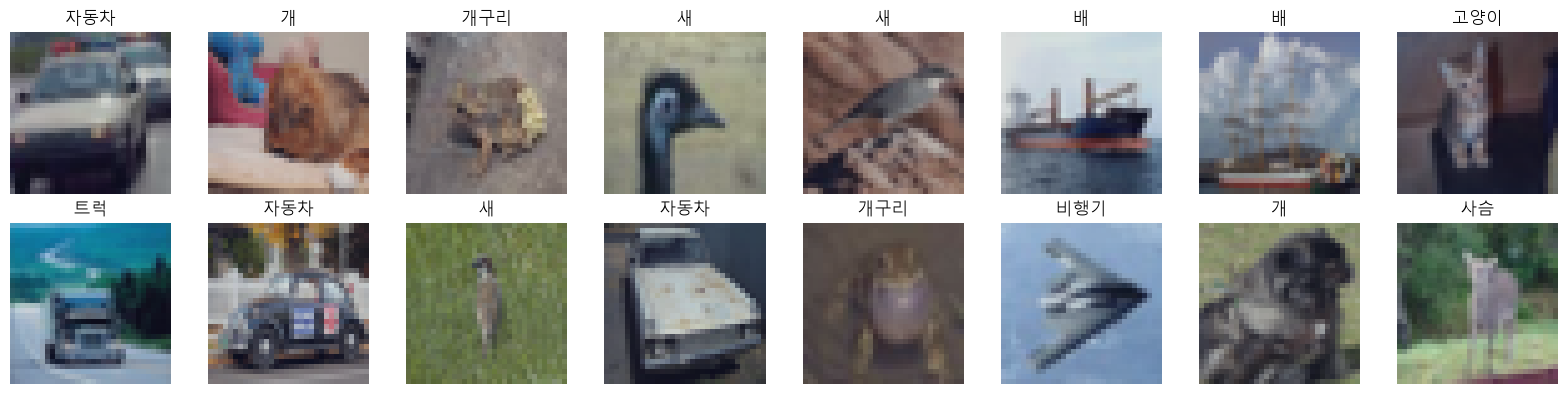

In [8]:
# 샘플 이미지 시각화
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = images[i].permute(1, 2, 0)   # (C,H,W) → (H,W,C)
    img = img * 0.2 + 0.45             # 정규화 역변환 (근사)
    ax.imshow(img.clamp(0, 1))
    ax.set_title(CLASSES[labels[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()


In [10]:
# 모델 클래스 작성

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # 특징 추출부 (Feature Extractor)
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # (3,32,32) → (32,32,32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # (32,16,16)
            nn.Dropout2d(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (64,16,16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # (64,8,8)
            nn.Dropout2d(0.25),
        )

        # 분류부 (Classifier)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = SimpleCNN(num_classes=10).to(device)
print(model)
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ce

In [11]:
# 훈련 및 평가 함수

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (pred.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred  = model(X)
            total_loss += criterion(pred, y).item()
            correct    += (pred.argmax(1) == y).sum().item()
            total      += y.size(0)

    return total_loss / len(loader), correct / total


In [12]:
# 학습(훈련) 설계

EPOCHS = 30
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [13]:
# 학습(훈련) 실행
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc = eval_epoch(model, test_loader,  criterion, device)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        torch.save(model.state_dict(), "cnn_best.pt")

    if epoch % 5 == 0:
        print(f"Epoch {epoch:>3} | Train {tr_loss:.4f}/{tr_acc:.2%} | Val {va_loss:.4f}/{va_acc:.2%}")

print(f"\n최고 검증 정확도: {best_acc:.2%}")


KeyboardInterrupt: 

In [ ]:
# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="validation")
axes[0].set_title("loss curve")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="validation")
axes[1].set_title("accuracy curve")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cnn_training_curve.png", dpi=100, bbox_inches="tight")
plt.show()